# University Clustering Analysis: Identifying Peer Groups Using K-means Clustering Algorithm

In [1]:
#Import necessary Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.cluster import KMeans

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
Univ = pd.read_csv("Universities.csv")
Univ.head()

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,Brown,1310,89,22,13,22704,94
1,CalTech,1415,100,25,6,63575,81
2,CMU,1260,62,59,9,25026,72
3,Columbia,1310,76,24,12,31510,88
4,Cornell,1280,83,33,13,21864,90


In [4]:
Univ.iloc[:,1:].head() #Removing Universities Name

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,1310,89,22,13,22704,94
1,1415,100,25,6,63575,81
2,1260,62,59,9,25026,72
3,1310,76,24,12,31510,88
4,1280,83,33,13,21864,90


In [6]:
# Standardisation function

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [8]:
scaled_Univ_df = scaler.fit_transform(Univ.iloc[:,1:])
scaled_Univ_df[:,5]

array([ 0.82030265, -0.64452351, -1.65863393,  0.14422904,  0.36958691,
        0.93298158,  0.93298158,  0.59494478,  1.15833946,  0.0315501 ,
        0.48226584,  0.25690797,  0.82030265, -0.75720245,  0.93298158,
       -1.99667073,  0.70762371, -2.22202861, -0.98256032,  0.0315501 ,
       -0.19380777,  0.36958691,  0.59494478, -1.77131286,  1.04566052])

In [9]:
wcss =[]
for i in range(1,11):
    kmeans = KMeans(n_clusters =i, n_init='auto', random_state=42)
    kmeans.fit(scaled_Univ_df)
    wcss.append(kmeans.inertia_)

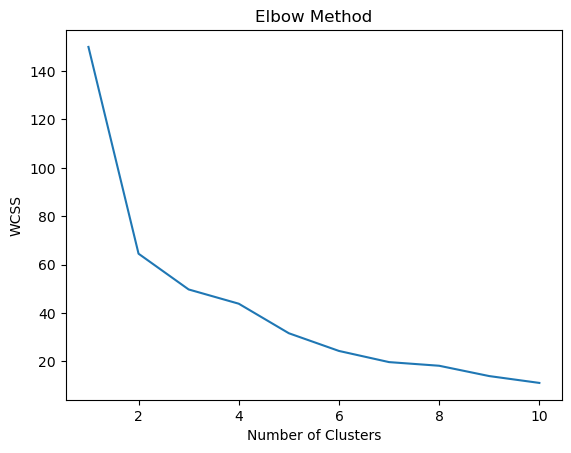

In [10]:
plt.plot(range(1,11),wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [12]:
## Build Cluster Algorithm

from sklearn.cluster import KMeans

#Initialize KMeans with n_itit = "auto" (or n_init=10) to supress the warning

cluster_new = KMeans(n_clusters =3, n_init="auto", random_state = 42)

#Fit the model
cluster_new.fit(scaled_Univ_df)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [13]:
cluster_new.labels_


array([2, 0, 1, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 2,
       2, 1, 2], dtype=int32)

In [14]:
#Assign cluster to the data set

Univ["Clusterid_new"] = cluster_new.labels_

In [15]:
Univ.head()

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,Clusterid_new
0,Brown,1310,89,22,13,22704,94,2
1,CalTech,1415,100,25,6,63575,81,0
2,CMU,1260,62,59,9,25026,72,1
3,Columbia,1310,76,24,12,31510,88,2
4,Cornell,1280,83,33,13,21864,90,2


In [16]:
cluster_new.cluster_centers_

array([[ 0.88122441,  0.5787432 , -0.24316128, -1.56078563,  2.38759968,
        -0.3064867 ],
       [-1.43266468, -1.54821683,  1.48138682,  1.07398111, -0.99079432,
        -1.43327606],
       [ 0.4019729 ,  0.47834204, -0.4942352 , -0.19543032,  0.06879803,
         0.5419194 ]])

In [17]:
Univ[Univ["Clusterid_new"]==0]

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,Clusterid_new
1,CalTech,1415,100,25,6,63575,81,0
9,JohnsHopkins,1305,75,44,7,58691,87,0


In [18]:
Univ[Univ["Clusterid_new"]==1]

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,Clusterid_new
2,CMU,1260,62,59,9,25026,72,1
13,PennState,1081,38,54,18,10185,80,1
15,Purdue,1005,28,90,19,9066,69,1
17,TexasA&M,1075,49,67,25,8704,67,1
20,UMichigan,1180,65,68,16,15470,85,1
23,UWisconsin,1085,40,69,15,11857,71,1


In [19]:
Univ[Univ["Clusterid_new"]==2]

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,Clusterid_new
0,Brown,1310,89,22,13,22704,94,2
3,Columbia,1310,76,24,12,31510,88,2
4,Cornell,1280,83,33,13,21864,90,2
5,Dartmouth,1340,89,23,10,32162,95,2
6,Duke,1315,90,30,12,31585,95,2
7,Georgetown,1255,74,24,12,20126,92,2
8,Harvard,1400,91,14,11,39525,97,2
10,MIT,1380,94,30,10,34870,91,2
11,Northwestern,1260,85,39,11,28052,89,2
12,NotreDame,1255,81,42,13,15122,94,2


In [20]:
## Model Evaluation - Silhouette score

In [21]:
from sklearn.metrics import silhouette_score

In [22]:
#Compute the average silhouette_score

silhouette_avg = silhouette_score(scaled_Univ_df, Univ.Clusterid_new)
print(f"Average silhouette score: {silhouette_avg}")

Average silhouette score: 0.4222470059484323


In [23]:
import matplotlib.pyplot as plt

#Get cluster assignments
clusters = Univ["Clusterid_new"].values

In [24]:
clusters

array([2, 0, 1, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 2,
       2, 1, 2], dtype=int32)

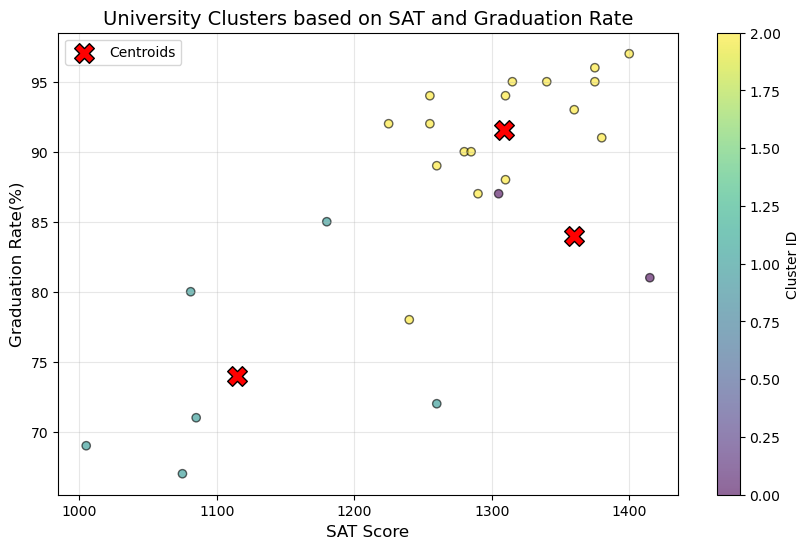

In [33]:
# Plot the clustered data using original(Unscaled )Values

plt.figure(figsize = (10,6))
scatter = plt.scatter(Univ["SAT"], Univ["GradRate"], c = clusters, cmap ="viridis", alpha = 0.6, edgecolor = "k")

if hasattr(cluster_new, 'cluster_centers_'):
    if "scaler" in globals():
        centroids_original = scaler.inverse_transform(cluster_new.cluster_centers_)

        sat_idx = 0
        gradrate_idx = -1

        plt.scatter(
            centroids_original[:, sat_idx],
            centroids_original[:, gradrate_idx],
            marker='X',
            s=200,
            c='red',
            edgecolor='k',
            linewidth=1,
            label='Centroids'
        )
    else:
        plt.scatter(
            cluster_new.cluster_centers_[:, 0],
            cluster_new.cluster_centers_[:, -1],
            marker='X',
            s=200,
            c='red',
            edgecolor='k',
            linewidth=1,
            label='Centroids'
        )

plt.title("University Clusters based on SAT and Graduation Rate", fontsize=14)
plt.xlabel("SAT Score", fontsize =12)
plt.ylabel("Graduation Rate(%)", fontsize =12)
plt.colorbar(scatter, label = "Cluster ID")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()
                    